In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

In [2]:
zip_path = "API_SP.POP.TOTL_DS2_EN_csv_v2_3107.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("population_data")

In [3]:
import os

files = os.listdir("population_data")
print(files)

['API_SP.POP.TOTL_DS2_EN_csv_v2_3107.csv', 'Metadata_Country_API_SP.POP.TOTL_DS2_EN_csv_v2_3107.csv', 'Metadata_Indicator_API_SP.POP.TOTL_DS2_EN_csv_v2_3107.csv']


In [4]:
df = pd.read_csv(
    "population_data/API_SP.POP.TOTL_DS2_EN_csv_v2_3107.csv",
    skiprows=4
)

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,108785.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,788844284.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,43844111.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106384410.0,108754449.0,...,440150152.0,451395343.0,462522286.0,473687685.0,484978794.0,496366058.0,508318102.0,520655398.0,532809933.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,39040039.0,NaN


In [5]:
print(df.columns)

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')


In [6]:
year = "2023"

population = df[year].dropna()

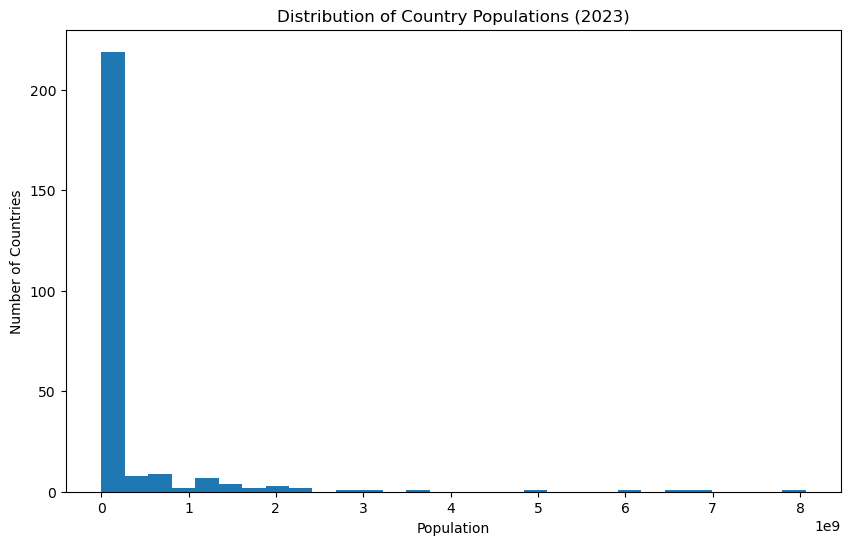

In [7]:
plt.figure(figsize=(10,6))

plt.hist(population, bins=30)

plt.title("Distribution of Country Populations (2023)")
plt.xlabel("Population")
plt.ylabel("Number of Countries")

plt.show()

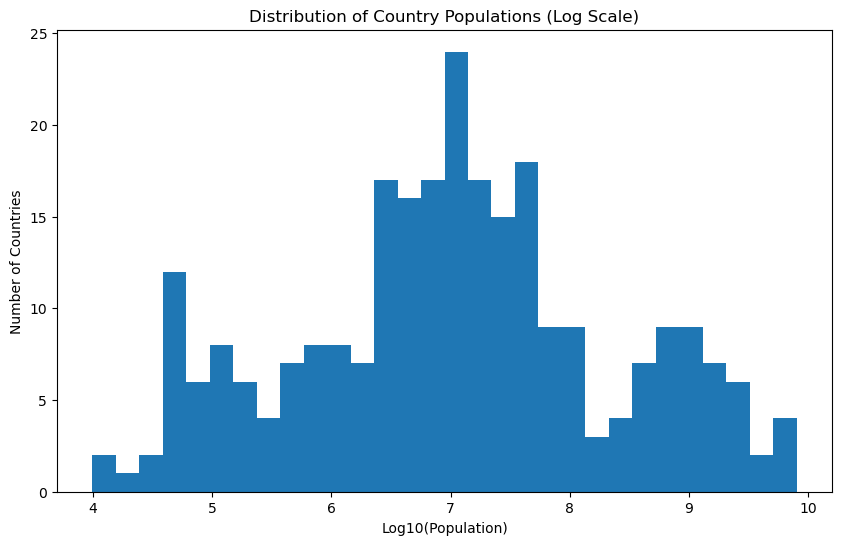

In [8]:
import numpy as np

plt.figure(figsize=(10,6))

plt.hist(np.log10(population), bins=30)

plt.title("Distribution of Country Populations (Log Scale)")
plt.xlabel("Log10(Population)")
plt.ylabel("Number of Countries")

plt.show()

In [9]:
top10 = df[["Country Name", year]].dropna()

top10 = top10.sort_values(by=year, ascending=False).head(10)

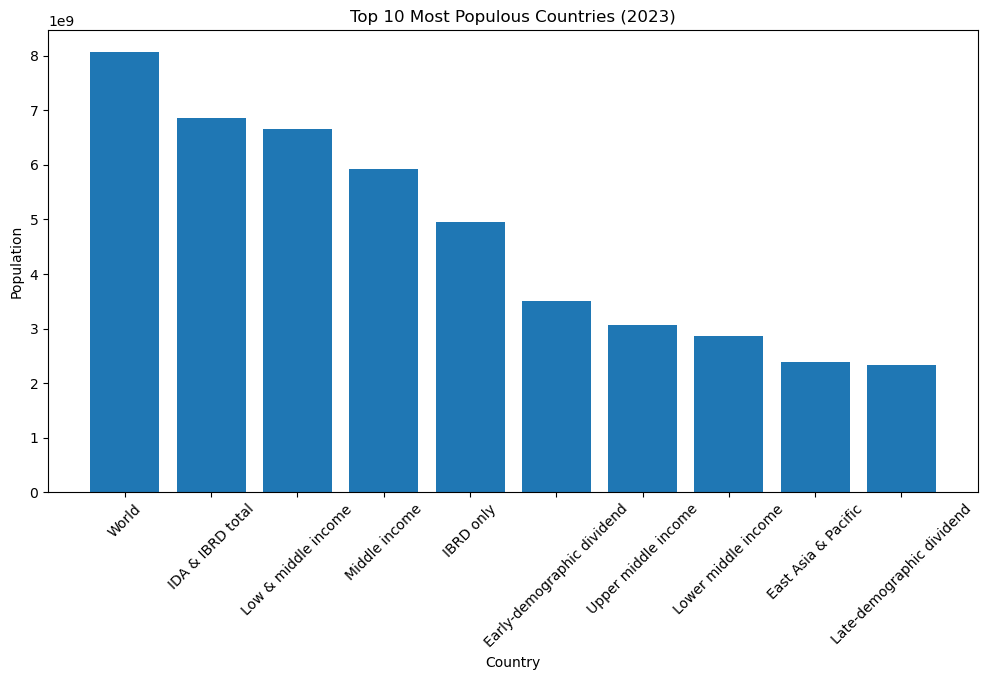

In [10]:
plt.figure(figsize=(12,6))

plt.bar(top10["Country Name"], top10[year])

plt.xticks(rotation=45)

plt.title("Top 10 Most Populous Countries (2023)")
plt.xlabel("Country")
plt.ylabel("Population")

plt.show()

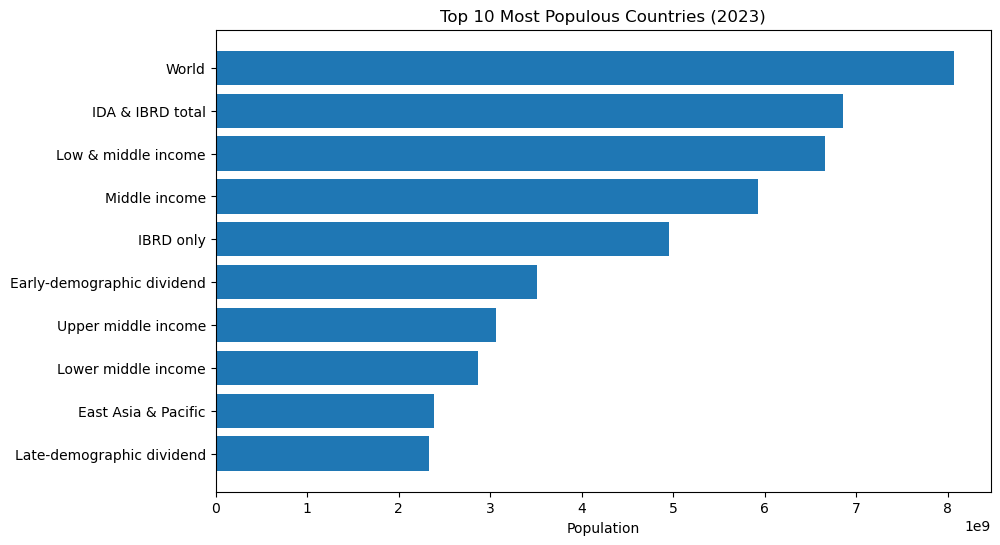

In [11]:
plt.figure(figsize=(10,6))

plt.barh(top10["Country Name"], top10[year])

plt.title("Top 10 Most Populous Countries (2023)")
plt.xlabel("Population")

plt.gca().invert_yaxis()

plt.show()